In [2]:
import re
import math
from collections import Counter
import matplotlib.pyplot as plt
from nltk.corpus import stopwords

###  Zipf's Law
Zipf's Law states that in natural language, the frequency of a word is inversely proportional to its rank in the frequency table. The most frequent word occurs about twice as often as the second most frequent, and so on.

In [3]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/aakashshrestha/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/aakashshrestha/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

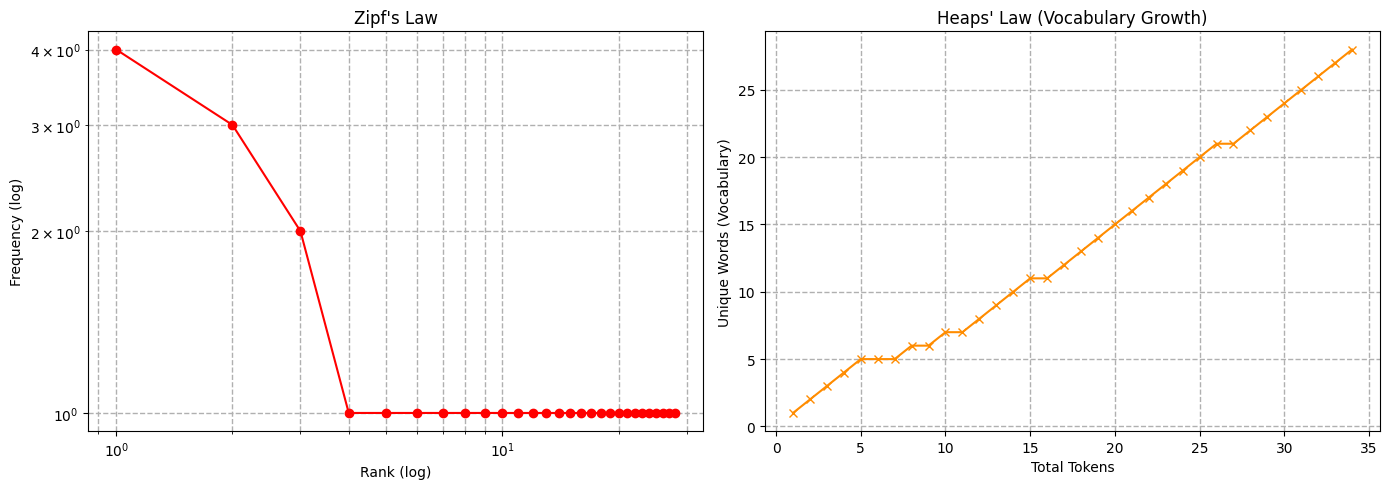

In [4]:


# Load English stop words
stop_words = set(stopwords.words('english'))
tokens = re.findall(r'\b\w+\b', text.lower())
tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

# Zipf’s Law: Frequency and rank
freq = Counter(tokens)
sorted_items = sorted(freq.items(), key=lambda x: x[1], reverse=True)#-->[(,),(,)]
words, freqs = zip(*sorted_items) #unzipping
ranks = range(1, len(freqs) + 1)

# Heaps’ Law: Vocabulary growth
vocab = set()
vocab_size = []
token_counts = []

for i, word in enumerate(tokens, 1):
    vocab.add(word)
    vocab_size.append(len(vocab))
    token_counts.append(i)

# Plot both in subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Zipf’s Law Plot
axs[0].loglog(ranks, freqs, marker='o', color='red')
axs[0].set_title("Zipf's Law")
axs[0].set_xlabel("Rank (log)")
axs[0].set_ylabel("Frequency (log)")
axs[0].grid(True, which='both', linestyle='--', linewidth=1)

# Heaps’ Law Plot
axs[1].plot(token_counts, vocab_size, marker='x', color='darkorange')
axs[1].set_title("Heaps' Law (Vocabulary Growth)")
axs[1].set_xlabel("Total Tokens")
axs[1].set_ylabel("Unique Words (Vocabulary)")
axs[1].grid(True, linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

### TF-IDF

In [5]:


# Steve Wozniak Sample Speech Text
text = """I said life is not about accomplishment; it's about happiness and my formula for happiness.

There's a formula for creating happiness, and it couldn't be more simple. Happiness equals smiles minus frowns.

In life and business, you can't stop things from going wrong, but you do get to decide how to react in those situations.

Make life fun, use your brain, be kind, be a leader, and help people."""


# Split into paragraphs
documents = [p.strip() for p in text.split('\n\n') if p.strip()]

for each_doc in documents:
    print(each_doc)


I said life is not about accomplishment; it's about happiness and my formula for happiness.
There's a formula for creating happiness, and it couldn't be more simple. Happiness equals smiles minus frowns.
In life and business, you can't stop things from going wrong, but you do get to decide how to react in those situations.
Make life fun, use your brain, be kind, be a leader, and help people.


#### Basic tokenizer and preprocessing


In [6]:
# We can have our own set of stop words
stop_words = set([
    'the', 'is', 'at', 'which', 'on', 'for', 'to', 'be', 'with', 'a', 'an', 'and', 'of', 'this', 'from', 'i', 'you',
    'in', 'it', 'that', 'just', 'your', 'have', 'has', 'as', 'are', 'was', 'were', 'but', 'by', 'not', 'or', 'so', 'if'
])  

def tokenize(text):
    tokens = re.findall(r'\b\w+\b', text.lower())
    return [t for t in tokens if t not in stop_words and len(t) > 2]

# Tokenize all docs
tokenized_docs = [tokenize(doc) for doc in documents]

for each_tokenize_doc in tokenized_docs:
    print(each_tokenize_doc)


['said', 'life', 'about', 'accomplishment', 'about', 'happiness', 'formula', 'happiness']
['there', 'formula', 'creating', 'happiness', 'couldn', 'more', 'simple', 'happiness', 'equals', 'smiles', 'minus', 'frowns']
['life', 'business', 'can', 'stop', 'things', 'going', 'wrong', 'get', 'decide', 'how', 'react', 'those', 'situations']
['make', 'life', 'fun', 'use', 'brain', 'kind', 'leader', 'help', 'people']


#### Calculate TF for each document

TF(term) = (Number of times the term appears in a document) / (Total number of terms in the document)

In [7]:
def compute_tf(tokens):
    tf_counter = Counter(tokens)
    total_tokens = len(tokens)
    tf = {term: count / total_tokens for term, count in tf_counter.items()}
    return tf

tf_docs = [compute_tf(doc) for doc in tokenized_docs]

for each_tf_doc in tf_docs:
    print(each_tf_doc)


{'said': 0.125, 'life': 0.125, 'about': 0.25, 'accomplishment': 0.125, 'happiness': 0.25, 'formula': 0.125}
{'there': 0.08333333333333333, 'formula': 0.08333333333333333, 'creating': 0.08333333333333333, 'happiness': 0.16666666666666666, 'couldn': 0.08333333333333333, 'more': 0.08333333333333333, 'simple': 0.08333333333333333, 'equals': 0.08333333333333333, 'smiles': 0.08333333333333333, 'minus': 0.08333333333333333, 'frowns': 0.08333333333333333}
{'life': 0.07692307692307693, 'business': 0.07692307692307693, 'can': 0.07692307692307693, 'stop': 0.07692307692307693, 'things': 0.07692307692307693, 'going': 0.07692307692307693, 'wrong': 0.07692307692307693, 'get': 0.07692307692307693, 'decide': 0.07692307692307693, 'how': 0.07692307692307693, 'react': 0.07692307692307693, 'those': 0.07692307692307693, 'situations': 0.07692307692307693}
{'make': 0.1111111111111111, 'life': 0.1111111111111111, 'fun': 0.1111111111111111, 'use': 0.1111111111111111, 'brain': 0.1111111111111111, 'kind': 0.11111

#### Calculate IDF for all terms


##### IDF(term) =  log( Total number of documents  / number of documents containing term ) 
---
##### IDF(term) = log((Total documents + 1) / (Documents with term + 1)) + 1

In [8]:
def compute_idf(tokenized_documents):
    N = len(tokenized_documents)
    all_terms = set(term for doc in tokenized_documents for term in doc)
    idf = {}
    for term in all_terms:
        containing_docs = sum(1 for doc in tokenized_documents if term in doc)
        idf[term] = math.log((N + 1) / (containing_docs + 1)) + 1  
    return idf

idf = compute_idf(tokenized_docs)

for each_idf_doc in tf_docs:
    print(each_idf_doc)

{'said': 0.125, 'life': 0.125, 'about': 0.25, 'accomplishment': 0.125, 'happiness': 0.25, 'formula': 0.125}
{'there': 0.08333333333333333, 'formula': 0.08333333333333333, 'creating': 0.08333333333333333, 'happiness': 0.16666666666666666, 'couldn': 0.08333333333333333, 'more': 0.08333333333333333, 'simple': 0.08333333333333333, 'equals': 0.08333333333333333, 'smiles': 0.08333333333333333, 'minus': 0.08333333333333333, 'frowns': 0.08333333333333333}
{'life': 0.07692307692307693, 'business': 0.07692307692307693, 'can': 0.07692307692307693, 'stop': 0.07692307692307693, 'things': 0.07692307692307693, 'going': 0.07692307692307693, 'wrong': 0.07692307692307693, 'get': 0.07692307692307693, 'decide': 0.07692307692307693, 'how': 0.07692307692307693, 'react': 0.07692307692307693, 'those': 0.07692307692307693, 'situations': 0.07692307692307693}
{'make': 0.1111111111111111, 'life': 0.1111111111111111, 'fun': 0.1111111111111111, 'use': 0.1111111111111111, 'brain': 0.1111111111111111, 'kind': 0.11111

#### Calculate TF-IDF for each doc

In [9]:
def compute_tfidf(tf, idf):
    tfidf = {term: tf_val * idf.get(term, 0) for term, tf_val in tf.items()}
    return tfidf

tfidf_docs = [compute_tfidf(tf_doc, idf) for tf_doc in tf_docs]

for each_tfidf_doc in tfidf_docs:
    print(each_tfidf_doc)


{'said': 0.2395363414842694, 'life': 0.1528929439142762, 'about': 0.4790726829685388, 'accomplishment': 0.2395363414842694, 'happiness': 0.3777064059414977, 'formula': 0.18885320297074884}
{'there': 0.15969089432284625, 'formula': 0.12590213531383254, 'creating': 0.15969089432284625, 'happiness': 0.2518042706276651, 'couldn': 0.15969089432284625, 'more': 0.15969089432284625, 'simple': 0.15969089432284625, 'equals': 0.15969089432284625, 'smiles': 0.15969089432284625, 'minus': 0.15969089432284625, 'frowns': 0.15969089432284625}
{'life': 0.09408796548570844, 'business': 0.14740697937493502, 'can': 0.14740697937493502, 'stop': 0.14740697937493502, 'things': 0.14740697937493502, 'going': 0.14740697937493502, 'wrong': 0.14740697937493502, 'get': 0.14740697937493502, 'decide': 0.14740697937493502, 'how': 0.14740697937493502, 'react': 0.14740697937493502, 'those': 0.14740697937493502, 'situations': 0.14740697937493502}
{'make': 0.21292119243046168, 'life': 0.13590483903491218, 'fun': 0.2129211

#### Show top terms in the first paragraph

In [10]:
first_doc_tfidf = tfidf_docs[0]
top_terms = sorted(first_doc_tfidf.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top terms in the first paragraph (from scratch TF-IDF):")
for term, score in top_terms:
    print(f"{term}: {score:.4f}")


Top terms in the first paragraph (from scratch TF-IDF):
about: 0.4791
happiness: 0.3777
said: 0.2395
accomplishment: 0.2395
formula: 0.1889
life: 0.1529


In [11]:
# Show in a datafrrame
import pandas as pd

all_tokens = [token for doc in tokenized_docs for token in doc]

corpus_tf = compute_tf(all_tokens)

corpus_tfidf = compute_tfidf(corpus_tf, idf)

# Create a DataFrame
import pandas as pd
df_corpus = pd.DataFrame({
    'Term': list(corpus_tf.keys()),
    'TF': [round(corpus_tf[t], 4) for t in corpus_tf],
    'IDF': [round(idf[t], 4) for t in corpus_tf],
    'TF-IDF': [round(corpus_tfidf[t], 4) for t in corpus_tf]
})

df_corpus = df_corpus.sort_values(by='TF-IDF', ascending=False)

# Show top 20 terms in the whole corpus
print("Top terms in the whole corpus:")
print("_"*40)
print(df_corpus.head(20))


Top terms in the whole corpus:
________________________________________
          Term      TF     IDF  TF-IDF
4    happiness  0.0952  1.5108  0.1439
2        about  0.0476  1.9163  0.0913
1         life  0.0714  1.2231  0.0874
5      formula  0.0476  1.5108  0.0719
0         said  0.0238  1.9163  0.0456
27        make  0.0238  1.9163  0.0456
22      decide  0.0238  1.9163  0.0456
23         how  0.0238  1.9163  0.0456
24       react  0.0238  1.9163  0.0456
25       those  0.0238  1.9163  0.0456
26  situations  0.0238  1.9163  0.0456
29         use  0.0238  1.9163  0.0456
28         fun  0.0238  1.9163  0.0456
20       wrong  0.0238  1.9163  0.0456
30       brain  0.0238  1.9163  0.0456
31        kind  0.0238  1.9163  0.0456
32      leader  0.0238  1.9163  0.0456
33        help  0.0238  1.9163  0.0456
21         get  0.0238  1.9163  0.0456
17        stop  0.0238  1.9163  0.0456
